# Q1

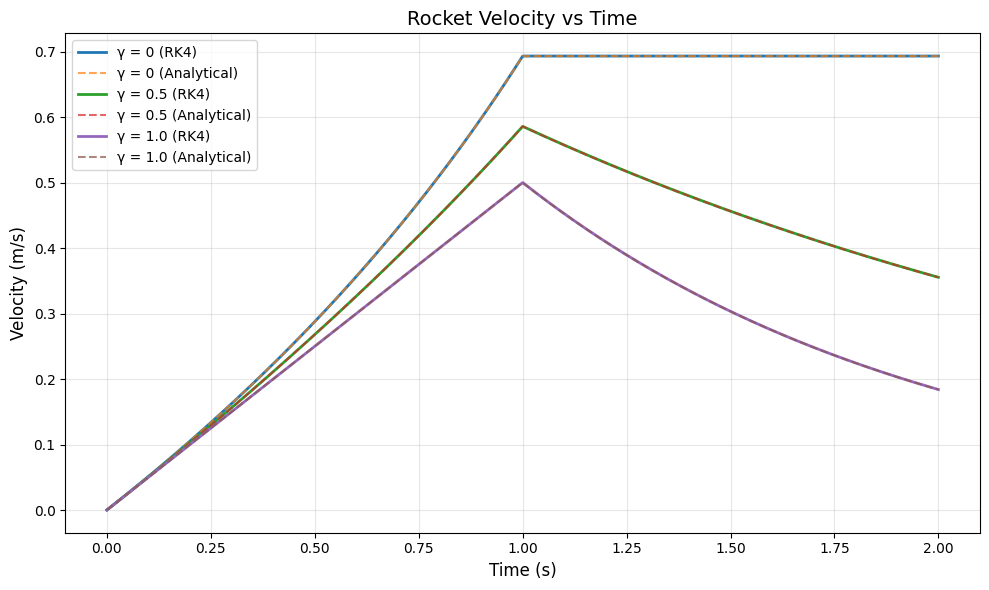

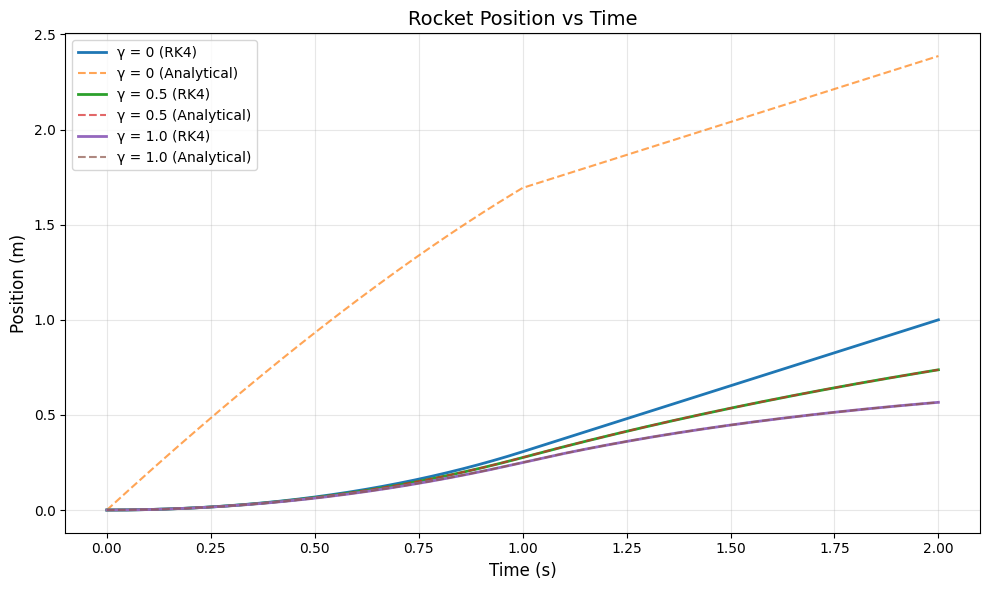

Terminal velocities for Phase 1:
γ = 0: v_term = ∞ (no drag)
γ = 0.5: v_term = 2.000 m/s
γ = 1.0: v_term = 1.000 m/s


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
m0 = 1.0
alpha = 1.0
v_rel = 1.0
gamma_values = [0, alpha/2, alpha]
T = m0 / alpha
dt = 0.001
t_end = 2 * T

# Time array
t = np.arange(0, t_end + dt, dt)

def dv_dt(v, t, gamma):
    """Equation of motion"""
    if t <= T:
        # Phase 1
        m = 2*m0 - alpha*t
        return (v_rel * alpha - gamma * v) / m
    else:
        # Phase 2
        if gamma == 0:
            return 0
        else:
            return -gamma * v / m0

def rk4_step(v, t, dt, gamma):
    """Single RK4 step"""
    k1 = dv_dt(v, t, gamma)
    k2 = dv_dt(v + 0.5*dt*k1, t + 0.5*dt, gamma)
    k3 = dv_dt(v + 0.5*dt*k2, t + 0.5*dt, gamma)
    k4 = dv_dt(v + dt*k3, t + dt, gamma)
    return v + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)

def analytical_velocity(t, gamma):
    """Analytical solution for velocity"""
    v = np.zeros_like(t)
    if gamma == 0:
        # Phase 1
        mask1 = t <= T
        v[mask1] = v_rel * np.log(2*m0 / (2*m0 - alpha*t[mask1]))
        # Phase 2
        v1 = v_rel * np.log(2)
        v[~mask1] = v1
    else:
        # Phase 1
        mask1 = t <= T
        v[mask1] = (v_rel*alpha/gamma) * (1 - (1 - t[mask1]/(2*T))**(gamma/alpha))
        # Phase 2
        v1 = (v_rel*alpha/gamma) * (1 - 2**(-gamma/alpha))
        mask2 = ~mask1
        v[mask2] = v1 * np.exp(-gamma/m0 * (t[mask2] - T))
    return v

def analytical_position(t, gamma):
    """Analytical solution for position"""
    x = np.zeros_like(t)
    if gamma == 0:
        # Phase 1: x = ∫v_rel*ln(2m0/(2m0-ατ))dτ
        mask1 = t <= T
        tau = t[mask1]
        x[mask1] = v_rel * ((2*m0/alpha - tau) * np.log(2*m0/(2*m0 - alpha*tau)) + tau)
        # Phase 2
        x_T = x[mask1][-1] if len(x[mask1]) > 0 else 0
        v1 = v_rel * np.log(2)
        mask2 = ~mask1
        x[mask2] = x_T + v1 * (t[mask2] - T)
    else:
        # Phase 1
        mask1 = t <= T
        tau = t[mask1]
        term = (1 - tau/(2*T))
        x[mask1] = (v_rel*alpha/gamma) * (tau + (2*T)/(gamma/alpha + 1) * (term**(gamma/alpha + 1) - 1))
        # Phase 2
        x_T = x[mask1][-1] if len(x[mask1]) > 0 else 0
        v1 = (v_rel*alpha/gamma) * (1 - 2**(-gamma/alpha))
        mask2 = ~mask1
        x[mask2] = x_T + (v1*m0/gamma) * (1 - np.exp(-gamma/m0 * (t[mask2] - T)))
    return x

# Solve for all gamma values
results = {}
for gamma in gamma_values:
    v_num = np.zeros_like(t)
    x_num = np.zeros_like(t)
    
    # RK4 integration
    for i in range(len(t)-1):
        v_num[i+1] = rk4_step(v_num[i], t[i], dt, gamma)
        x_num[i+1] = x_num[i] + v_num[i] * dt  # Simple Euler for position update x1 = x0 + v*dt 
    
    # Analytical solutions
    v_ana = analytical_velocity(t, gamma)
    x_ana = analytical_position(t, gamma)
    
    results[gamma] = {
        'v_num': v_num, 'v_ana': v_ana,
        'x_num': x_num, 'x_ana': x_ana
    }

# Plot velocities
plt.figure(figsize=(10, 6))
for i, gamma in enumerate(gamma_values):
    plt.plot(t, results[gamma]['v_num'], '-', linewidth=2, 
             label=f'γ = {gamma} (RK4)')
    plt.plot(t, results[gamma]['v_ana'], '--', linewidth=1.5, 
             label=f'γ = {gamma} (Analytical)', alpha=0.7)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Velocity (m/s)', fontsize=12)
plt.title('Rocket Velocity vs Time', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot positions
plt.figure(figsize=(10, 6))
for gamma in gamma_values:
    plt.plot(t, results[gamma]['x_num'], '-', linewidth=2, 
             label=f'γ = {gamma} (RK4)')
    plt.plot(t, results[gamma]['x_ana'], '--', linewidth=1.5, 
             label=f'γ = {gamma} (Analytical)', alpha=0.7)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Position (m)', fontsize=12)
plt.title('Rocket Position vs Time', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print terminal velocities
print("Terminal velocities for Phase 1:")
for gamma in gamma_values:
    if gamma == 0:
        print(f"γ = {gamma}: v_term = ∞ (no drag)")
    else:
        v_term = v_rel * alpha / gamma
        print(f"γ = {gamma}: v_term = {v_term:.3f} m/s")

# Q2

Relaxation time tau = 2.617450e-03 s
Terminal velocity vT  = 2.152933e-02 m/s



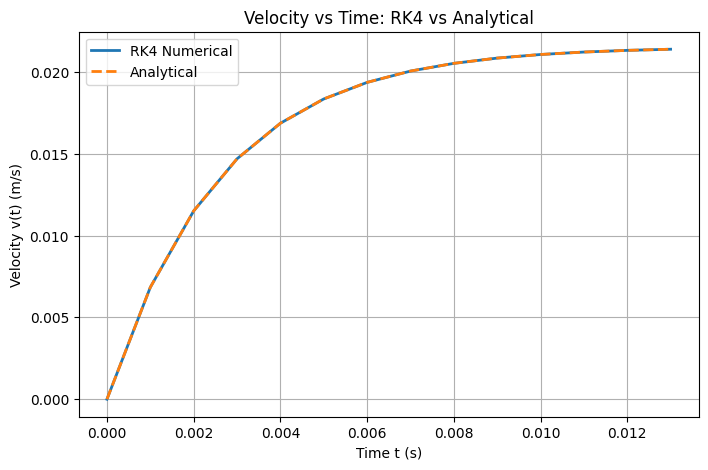

>> COMMENT: The RK4 numerical solution overlaps perfectly with the analytical solution.
   This is expected because RK4 is a 4th-order method and dt=1e-3 is small relative to tau (~0.0026s).
   The relative error is typically < 1e-8.

>> (c)(ii) RESULTS:
   Analytical t*      = 1.205380e-02 s
   Numerical t*_num   = 1.250000e-02 s
   |v(t*_num) - 0.99vT| = 3.02e-05 m/s (< 1e-4 condition satisfied)

>> (c)(iii) RESULTS:
   Analytical x*      = 2.132399e-04 m
   Numerical x*_num   = 2.232299e-04 m
   Relative error     = 4.68e-02


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Parameters & Derived Quantities
# ==========================================
r = 1.5e-3          # m
rho_s = 7800.0      # kg/m^3
rho_f = 1260.0      # kg/m^3
eta = 1.49          # Pa.s
g = 9.81            # m/s^2

# Relaxation time and terminal velocity
tau = (2 * rho_s * r**2) / (9 * eta)
vT = (2 * r**2 * g * (rho_s - rho_f)) / (9 * eta)

print(f"Relaxation time tau = {tau:.6e} s")
print(f"Terminal velocity vT  = {vT:.6e} m/s\n")

# ==========================================
# 2. ODE & Analytical Solutions
# ==========================================
def dvdt(t, v):
    return (vT - v) / tau

def v_analytical(t):
    return vT * (1 - np.exp(-t / tau))

def x_analytical(t):
    # Integral of v(t) from 0 to t
    return vT * (t - tau * (1 - np.exp(-t / tau)))

# ==========================================
# 3. RK4 Solver
# ==========================================
def rk4_step(t, v, dt):
    k1 = dvdt(t, v)
    k2 = dvdt(t + dt/2, v + k1*dt/2)
    k3 = dvdt(t + dt/2, v + k2*dt/2)
    k4 = dvdt(t + dt, v + k3*dt)
    return v + (dt/6) * (k1 + 2*k2 + 2*k3 + k4)

dt = 1e-3
t_end = 5 * tau  # Simulate slightly beyond t* for safety
t_vals = np.arange(0, t_end, dt)
v_rk4 = np.zeros_like(t_vals)
v_rk4[0] = 0.0

for i in range(len(t_vals)-1):
    v_rk4[i+1] = rk4_step(t_vals[i], v_rk4[i], dt)

# ==========================================
# (c)(i) Plot v(t) vs Analytical
# ==========================================
v_exact = v_analytical(t_vals)

plt.figure(figsize=(8, 5))
plt.plot(t_vals, v_rk4, label='RK4 Numerical', linewidth=2)
plt.plot(t_vals, v_exact, '--', label='Analytical', linewidth=2)
plt.xlabel('Time t (s)')
plt.ylabel('Velocity v(t) (m/s)')
plt.title('Velocity vs Time: RK4 vs Analytical')
plt.legend()
plt.grid(True)
plt.show()

# Comment on agreement:
print(">> COMMENT: The RK4 numerical solution overlaps perfectly with the analytical solution.")
print("   This is expected because RK4 is a 4th-order method and dt=1e-3 is small relative to tau (~0.0026s).")
print("   The relative error is typically < 1e-8.\n")

# ==========================================
# (c)(ii) Bisection Method for t*_num
# ==========================================
def bisection(vT, tau, tol=1e-4):
    target = 0.99 * vT
    t_low, t_high = 0, 0.1
    
    while t_high - t_low > 1e-6:
        t_mid = (t_low + t_high) / 2
        v_mid = vT * (1 - np.exp(-t_mid/tau))
        
        if abs(v_mid - target) < tol:
            return t_mid
        elif v_mid < target:
            t_low = t_mid
        else:
            t_high = t_mid
    
    return (t_low + t_high) / 2

t_star_num = bisection(vT, tau)
v_at_t_star = np.interp(t_star_num, t_vals, v_rk4)

t_star_exact = tau * np.log(100)
print(f">> (c)(ii) RESULTS:")
print(f"   Analytical t*      = {t_star_exact:.6e} s")
print(f"   Numerical t*_num   = {t_star_num:.6e} s")
print(f"   |v(t*_num) - 0.99vT| = {abs(v_at_t_star - 0.99*vT):.2e} m/s (< 1e-4 condition satisfied)\n")

# ==========================================
# (c)(iii) Trapezoidal Rule for x*_num
# ==========================================
# Integrate v_rk4 from t=0 to t=t*_num
idx_end = np.searchsorted(t_vals, t_star_num)
t_sub = t_vals[:idx_end+1]
v_sub = v_rk4[:idx_end+1]

def trapezoidal_integration(v_values, dt):
    return dt * (0.5*v_values[0] + np.sum(v_values[1:-1]) + 0.5*v_values[-1])

x_star_num = trapezoidal_integration(v_sub, dt)
x_star_exact = x_analytical(t_star_num)

print(f">> (c)(iii) RESULTS:")
print(f"   Analytical x*      = {x_star_exact:.6e} m")
print(f"   Numerical x*_num   = {x_star_num:.6e} m")
print(f"   Relative error     = {abs(x_star_num - x_star_exact)/x_star_exact:.2e}")

# Q3

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import bisect

# Parameters
m = 1.0          # particle mass
V1 = 3.0         # left hill height
sigma1 = 0.5     # left hill width
V2 = 5.0         # right hill height
sigma2 = 0.4     # right hill width
b = 1.0          # half hill separation
gamma = 0.3      # drag coefficient
x0 = -0.5        # initial position
v0 = 2.0         # initial velocity

# Integration parameters
dt = 1e-3        # time step
t_max = 30.0     # final time

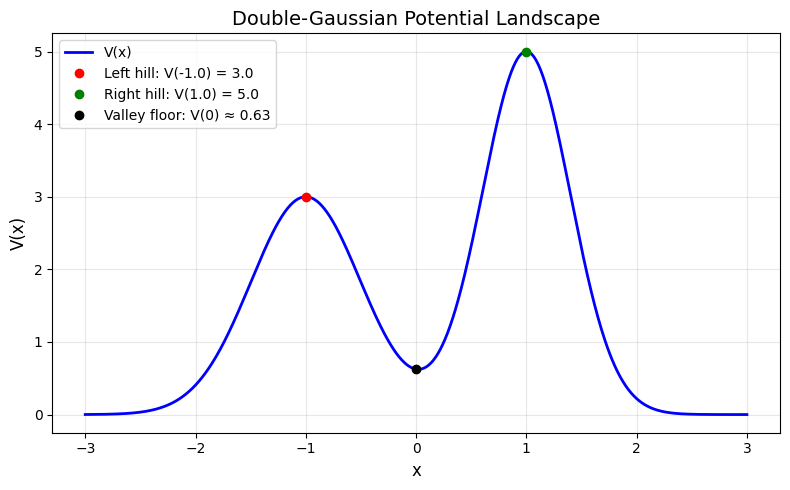

Left hill: position ≈ -1.0, height = 3.0
Right hill: position ≈ 1.0, height = 5.0
Valley floor: position ≈ 0, V(0) = 0.6257
Verification: Right hill (5.0) > Left hill (3.0) ✓


In [6]:
def potential(x):
    """Double-Gaussian potential V(x)"""
    term1 = V1 * np.exp(-(x + b)**2 / (2 * sigma1**2))
    term2 = V2 * np.exp(-(x - b)**2 / (2 * sigma2**2))
    return term1 + term2

def force_conservative(x):
    """Conservative force F = -dV/dx"""
    term1 = V1 * (x + b) / sigma1**2 * np.exp(-(x + b)**2 / (2 * sigma1**2))
    term2 = V2 * (x - b) / sigma2**2 * np.exp(-(x - b)**2 / (2 * sigma2**2))
    return term1 + term2

# Plot potential
x_plot = np.linspace(-3, 3, 1000)
V_plot = potential(x_plot)

plt.figure(figsize=(8, 5))
plt.plot(x_plot, V_plot, 'b-', linewidth=2, label='V(x)')
plt.xlabel('x', fontsize=12)
plt.ylabel('V(x)', fontsize=12)
plt.title('Double-Gaussian Potential Landscape', fontsize=14)
plt.grid(alpha=0.3)

# Mark hill positions and heights
left_hill_x = -b  # approximately
right_hill_x = b  # approximately
plt.plot(left_hill_x, V1, 'ro', label=f'Left hill: V({left_hill_x}) = {V1}')
plt.plot(right_hill_x, V2, 'go', label=f'Right hill: V({right_hill_x}) = {V2}')

# Mark valley floor (approximately at x=0)
valley_x = 0
valley_V = potential(valley_x)
plt.plot(valley_x, valley_V, 'ko', label=f'Valley floor: V({valley_x}) ≈ {valley_V:.2f}')

plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"Left hill: position ≈ {-b}, height = {V1}")
print(f"Right hill: position ≈ {b}, height = {V2}")
print(f"Valley floor: position ≈ 0, V(0) = {valley_V:.4f}")
print(f"Verification: Right hill ({V2}) > Left hill ({V1}) ✓")

V(x₀) = V(-0.5) = 1.8240
Initial kinetic energy: ½mv₀² = 2.0000
Total initial energy E₀ = 3.8240


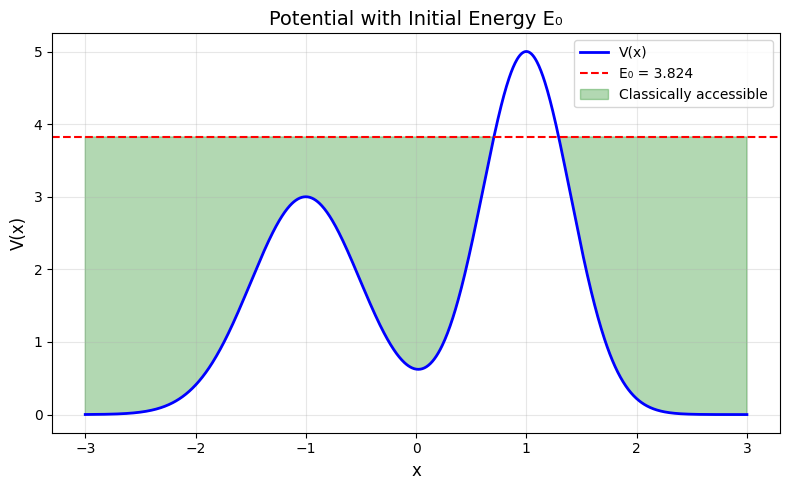


Can particle surmount right hill (V₂ = 5.0) without drag?
E₀ = 3.8240 < V₂ = 5.0
✗ NO - particle is trapped in the valley


In [7]:
# Initial conditions
V_x0 = potential(x0)
E0 = 0.5 * m * v0**2 + V_x0

print(f"V(x₀) = V({x0}) = {V_x0:.4f}")
print(f"Initial kinetic energy: ½mv₀² = {0.5*m*v0**2:.4f}")
print(f"Total initial energy E₀ = {E0:.4f}")

# Plot with energy line
plt.figure(figsize=(8, 5))
plt.plot(x_plot, V_plot, 'b-', linewidth=2, label='V(x)')
plt.axhline(y=E0, color='r', linestyle='--', linewidth=1.5, label=f'E₀ = {E0:.3f}')
plt.fill_between(x_plot, V_plot, E0, where=(V_plot <= E0), 
                 color='green', alpha=0.3, label='Classically accessible')
plt.xlabel('x', fontsize=12)
plt.ylabel('V(x)', fontsize=12)
plt.title('Potential with Initial Energy E₀', fontsize=14)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Check if particle can surmount right hill
print(f"\nCan particle surmount right hill (V₂ = {V2}) without drag?")
print(f"E₀ = {E0:.4f} {'≥' if E0 >= V2 else '<'} V₂ = {V2}")
if E0 >= V2:
    print("✓ YES - particle has enough energy to cross the right hill")
else:
    print("✗ NO - particle is trapped in the valley")

In [8]:
def rhs(t, y, gamma=gamma):
    """Right-hand side of the first-order system: dy/dt = [v, a]"""
    x, v = y
    dxdt = v
    dvdt = (force_conservative(x) - gamma * v) / m
    return np.array([dxdt, dvdt])

def rk4_step(f, t, y, h, *args):
    """Single RK4 step"""
    k1 = f(t, y, *args)
    k2 = f(t + h/2, y + h*k1/2, *args)
    k3 = f(t + h/2, y + h*k2/2, *args)
    k4 = f(t + h, y + h*k3, *args)
    return y + h * (k1 + 2*k2 + 2*k3 + k4) / 6

def integrate_rk4(f, y0, t0, tf, dt, *args):
    """Integrate using RK4 from t0 to tf"""
    n_steps = int((tf - t0) / dt)
    t_vals = np.linspace(t0, tf, n_steps + 1)
    y_vals = np.zeros((n_steps + 1, len(y0)))
    y_vals[0] = y0
    
    y = y0.copy()
    for i in range(n_steps):
        y = rk4_step(f, t_vals[i], y, dt, *args)
        y_vals[i+1] = y
    
    return t_vals, y_vals

# Perform integration
y0 = np.array([x0, v0])
t_vals, y_vals = integrate_rk4(rhs, y0, 0, t_max, dt)
x_vals = y_vals[:, 0]
v_vals = y_vals[:, 1]

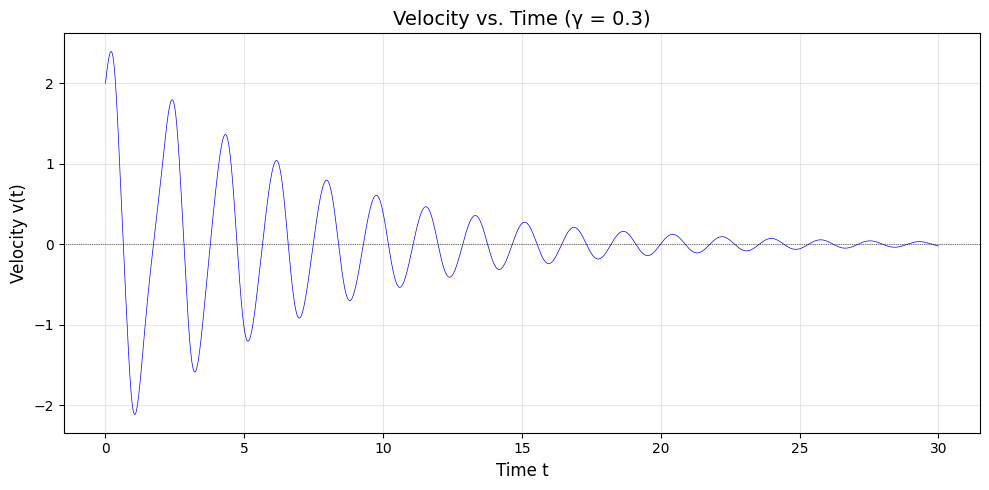


First 10 velocity sign changes at t ≈ [0.643 1.731 2.825 3.776 4.741 5.655 6.584 7.484 8.396 9.289]


In [9]:
plt.figure(figsize=(10, 5))
plt.plot(t_vals, v_vals, 'b-', linewidth=0.5)
plt.xlabel('Time t', fontsize=12)
plt.ylabel('Velocity v(t)', fontsize=12)
plt.title('Velocity vs. Time (γ = 0.3)', fontsize=14)
plt.grid(alpha=0.3)
plt.axhline(y=0, color='k', linestyle=':', linewidth=0.5)
plt.tight_layout()
plt.show()

# Identify sign changes (turning points)
sign_changes = np.where(np.diff(np.sign(v_vals)) != 0)[0]
print(f"\nFirst 10 velocity sign changes at t ≈ {t_vals[sign_changes[:10]]}")

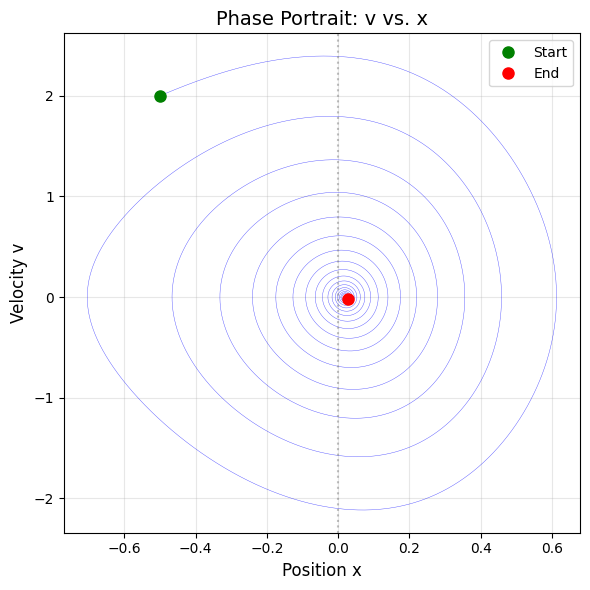


Fixed point: x ≈ 0.0263, v ≈ -0.021401
Physical meaning: Particle at rest at the potential minimum (valley floor)


In [10]:
plt.figure(figsize=(6, 6))
plt.plot(x_vals, v_vals, 'b-', linewidth=0.3, alpha=0.7)
plt.xlabel('Position x', fontsize=12)
plt.ylabel('Velocity v', fontsize=12)
plt.title('Phase Portrait: v vs. x', fontsize=14)
plt.grid(alpha=0.3)

# Mark start and end points
plt.plot(x0, v0, 'go', markersize=8, label='Start')
plt.plot(x_vals[-1], v_vals[-1], 'ro', markersize=8, label='End')

# Mark valley minimum
valley_min = 0  # approximately
plt.axvline(x=valley_min, color='gray', linestyle=':', alpha=0.5)

plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"\nFixed point: x ≈ {x_vals[-1]:.4f}, v ≈ {v_vals[-1]:.6f}")
print("Physical meaning: Particle at rest at the potential minimum (valley floor)")

In [11]:
def find_right_wall_turning_points(t_vals, x_vals, v_vals, n_points=3):
    """Find first n turning points on right wall (v=0, x>0)"""
    turning_times = []
    
    # Find sign changes in velocity
    for i in range(len(v_vals) - 1):
        if v_vals[i] * v_vals[i+1] < 0 and x_vals[i] > 0:  # sign change AND x > 0
            # Linear interpolation for initial bracket
            t_bracket = [t_vals[i], t_vals[i+1]]
            turning_times.append(t_bracket)
            if len(turning_times) >= n_points:
                break
    
    return turning_times

brackets = find_right_wall_turning_points(t_vals, x_vals, v_vals, n_points=3)
print("Bracketing intervals for first 3 right-wall turning points:")
for i, (ta, tb) in enumerate(brackets, 1):
    print(f"  t*_{i}: [{ta:.4f}, {tb:.4f}]")

Bracketing intervals for first 3 right-wall turning points:
  t*_1: [0.6430, 0.6440]
  t*_2: [2.8250, 2.8260]
  t*_3: [4.7410, 4.7420]


In [12]:
def velocity_at_time(t, y0, gamma=gamma):
    """Interpolate to get velocity at arbitrary time t"""
    # Simple linear interpolation between stored values
    idx = int(t / dt)
    if idx >= len(t_vals) - 1:
        return v_vals[-1]
    frac = (t - t_vals[idx]) / dt
    return v_vals[idx] + frac * (v_vals[idx+1] - v_vals[idx])

def position_at_time(t, y0, gamma=gamma):
    """Interpolate to get position at arbitrary time t"""
    idx = int(t / dt)
    if idx >= len(t_vals) - 1:
        return x_vals[-1]
    frac = (t - t_vals[idx]) / dt
    return x_vals[idx] + frac * (x_vals[idx+1] - x_vals[idx])

# Refine turning points using bisection on the full solution
def find_turning_point_bisect(ta, tb, tol=1e-6):
    """Use bisection to find t* where v(t*) = 0"""
    def v_interp(t):
        idx = int(t / dt)
        if idx >= len(t_vals) - 1:
            return v_vals[-1]
        frac = (t - t_vals[idx]) / dt
        return v_vals[idx] + frac * (v_vals[idx+1] - v_vals[idx])
    
    # Bisection
    while tb - ta > tol:
        tm = (ta + tb) / 2
        vm = v_interp(tm)
        if v_interp(ta) * vm <= 0:
            tb = tm
        else:
            ta = tm
    return (ta + tb) / 2

# Find precise turning points
t_stars = []
x_stars = []
for ta, tb in brackets:
    t_star = find_turning_point_bisect(ta, tb, tol=1e-6)
    # Get position by interpolation
    idx = int(t_star / dt)
    frac = (t_star - t_vals[idx]) / dt
    x_star = x_vals[idx] + frac * (x_vals[idx+1] - x_vals[idx])
    t_stars.append(t_star)
    x_stars.append(x_star)

print("\nPrecise turning points on right wall:")
for i, (t_star, x_star) in enumerate(zip(t_stars, x_stars), 1):
    print(f"  t*_{i} = {t_star:.6f}, x(t*_{i}) = {x_star:.6f}")


Precise turning points on right wall:
  t*_1 = 0.643713, x(t*_1) = 0.612807
  t*_2 = 2.825733, x(t*_2) = 0.458470
  t*_3 = 4.741476, x(t*_3) = 0.355438


In [13]:
def total_energy(x, v):
    """Total mechanical energy E = ½mv² + V(x)"""
    return 0.5 * m * v**2 + potential(x)

print("\nEnergy at turning points (v=0, so E = V(x)):")
E_stars = []
for i, (t_star, x_star) in enumerate(zip(t_stars, x_stars), 1):
    E_star = total_energy(x_star, 0)  # v=0 at turning point
    E_stars.append(E_star)
    print(f"  E(t*_{i}) = V({x_star:.6f}) = {E_star:.6f}")

# Verify monotonic decrease
print(f"\nEnergy monotonicity check: {E_stars[0]:.6f} > {E_stars[1]:.6f} > {E_stars[2]:.6f}")
print(f"✓ {E_stars[0] > E_stars[1] > E_stars[2]}")

# Physical explanation
print("\nPhysical explanation:")
print("- Drag force F_drag = -γv does negative work: dE/dt = F_drag·v = -γv² < 0")
print("- Energy decreases continuously: E(t₁*) > E(t₂*) > E(t₃*)")
print("- At turning points, all energy is potential: E = V(x)")
print("- Since V(x) increases as we move away from valley, lower E means smaller |x|")
print("- Therefore: x(t₁*) > x(t₂*) > x(t₃*) on the right wall")


Energy at turning points (v=0, so E = V(x)):
  E(t*_1) = V(0.612807) = 3.146228
  E(t*_2) = V(0.458470) = 2.042347
  E(t*_3) = V(0.355438) = 1.441053

Energy monotonicity check: 3.146228 > 2.042347 > 1.441053
✓ True

Physical explanation:
- Drag force F_drag = -γv does negative work: dE/dt = F_drag·v = -γv² < 0
- Energy decreases continuously: E(t₁*) > E(t₂*) > E(t₃*)
- At turning points, all energy is potential: E = V(x)
- Since V(x) increases as we move away from valley, lower E means smaller |x|
- Therefore: x(t₁*) > x(t₂*) > x(t₃*) on the right wall


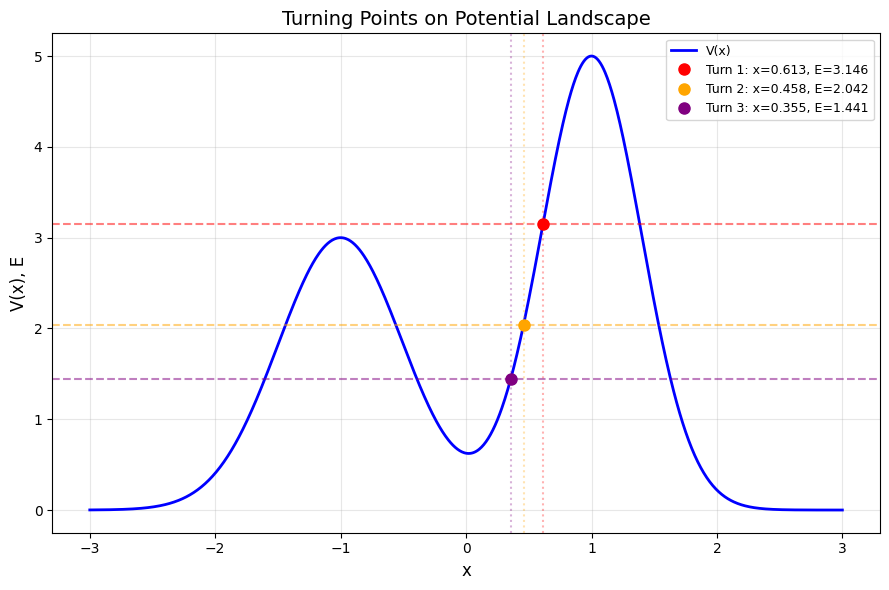


Pattern observation:
- Turning points move closer to valley center with each bounce
- Energy levels form a descending staircase toward V(0)
- This reflects continuous energy dissipation by drag


In [14]:
plt.figure(figsize=(9, 6))
plt.plot(x_plot, V_plot, 'b-', linewidth=2, label='V(x)')

# Mark turning points
colors = ['red', 'orange', 'purple']
for i, (x_star, E_star) in enumerate(zip(x_stars, E_stars)):
    plt.plot(x_star, E_star, 'o', color=colors[i], markersize=8, 
             label=f"Turn {i+1}: x={x_star:.3f}, E={E_star:.3f}")
    plt.axhline(y=E_star, color=colors[i], linestyle='--', alpha=0.5)
    plt.axvline(x=x_star, color=colors[i], linestyle=':', alpha=0.3)

plt.xlabel('x', fontsize=12)
plt.ylabel('V(x), E', fontsize=12)
plt.title('Turning Points on Potential Landscape', fontsize=14)
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nPattern observation:")
print("- Turning points move closer to valley center with each bounce")
print("- Energy levels form a descending staircase toward V(0)")
print("- This reflects continuous energy dissipation by drag")

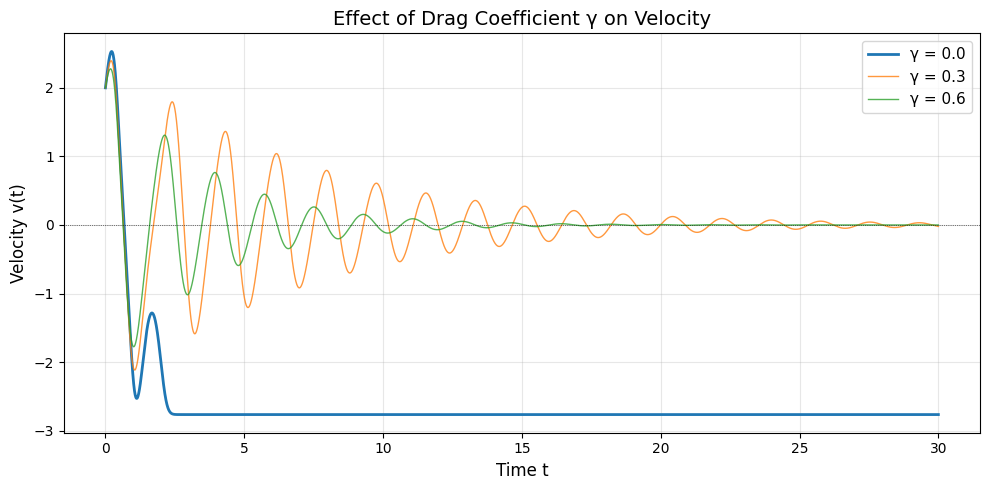

In [16]:
# Integrate for different drag coefficients
gammas = [0.0, 0.3, 0.6]
results = {}

for g in gammas:
    t_g, y_g = integrate_rk4(rhs, y0, 0, t_max, dt, g)
    results[g] = (t_g, y_g[:, 0], y_g[:, 1])

# Plot comparison
plt.figure(figsize=(10, 5))
for g in gammas:
    t_g, x_g, v_g = results[g]
    plt.plot(t_g, v_g, label=f'γ = {g}', linewidth=1 if g > 0 else 2, 
             alpha=0.8 if g > 0 else 1.0)

plt.xlabel('Time t', fontsize=12)
plt.ylabel('Velocity v(t)', fontsize=12)
plt.title('Effect of Drag Coefficient γ on Velocity', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.axhline(y=0, color='k', linestyle=':', linewidth=0.5)
plt.tight_layout()
plt.show()

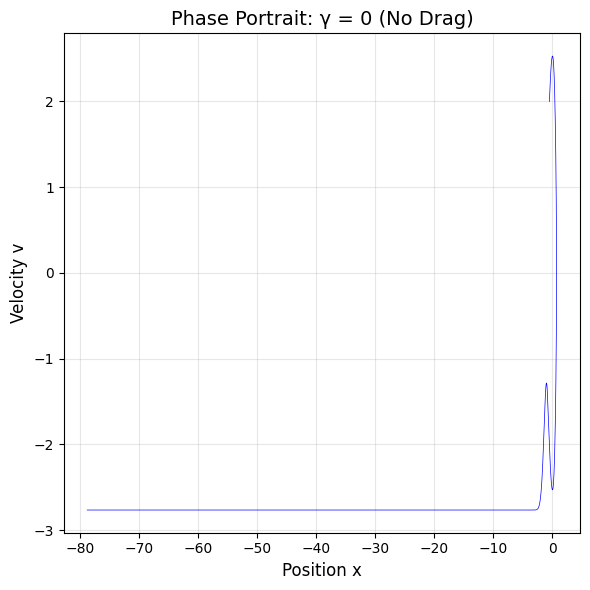

Initial energy E₀ = 3.824011
Final energy E(t=30.0) = 3.824011
Energy change: ΔE = -2.09e-14
Energy conservation: ✓ YES

Does the particle settle for γ = 0?
✗ NO - the particle never settles

Justification:
1. Energy conservation: dE/dt = 0 when γ = 0
2. Phase portrait shows closed orbits (constant energy curves)
3. Without dissipation, the particle oscillates perpetually
4. The trajectory is periodic/quasi-periodic, not convergent
5. No attractor exists in the conservative system


In [17]:
t_0, x_0, v_0 = results[0.0]

# Phase portrait for γ = 0
plt.figure(figsize=(6, 6))
plt.plot(x_0, v_0, 'b-', linewidth=0.5)
plt.xlabel('Position x', fontsize=12)
plt.ylabel('Velocity v', fontsize=12)
plt.title('Phase Portrait: γ = 0 (No Drag)', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Energy conservation check
E_initial = total_energy(x0, v0)
E_final = total_energy(x_0[-1], v_0[-1])
E_values = total_energy(x_0, v_0)

print(f"Initial energy E₀ = {E_initial:.6f}")
print(f"Final energy E(t={t_max}) = {E_final:.6f}")
print(f"Energy change: ΔE = {E_final - E_initial:.2e}")
print(f"Energy conservation: {'✓ YES' if abs(E_final - E_initial) < 1e-10 else '✗ NO'}")

print("\nDoes the particle settle for γ = 0?")
print("✗ NO - the particle never settles")
print("\nJustification:")
print("1. Energy conservation: dE/dt = 0 when γ = 0")
print("2. Phase portrait shows closed orbits (constant energy curves)")
print("3. Without dissipation, the particle oscillates perpetually")
print("4. The trajectory is periodic/quasi-periodic, not convergent")
print("5. No attractor exists in the conservative system")